#### Steup

###### Imports

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt

from svipy.normflow import inverseAutoRegressiveFlow
from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


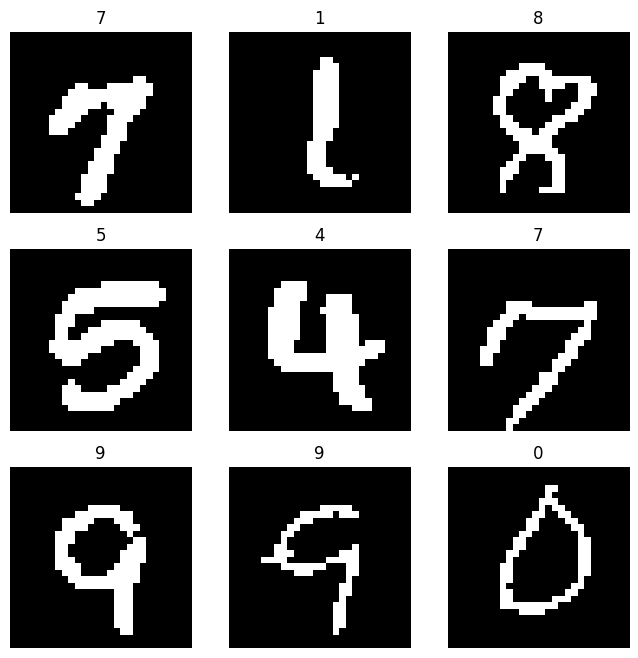

In [4]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(torch.argmax(label, dim=0).item()))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

In [37]:
def activeUnits(model, dataset, threshold=0.01, batchSize=256, device=device):
    """
    Burda et al.'s "active units" statistic: Var_x[mu(x)] per latent
    dimension, computed across the dataset. A dimension whose posterior
    mean barely moves across different inputs is \"dead\" -- carrying no
    information about x, regardless of what its logVar looks like.
    """
    
    model.eval()
    loader = DataLoader(dataset, batch_size=batchSize, shuffle=False)
    means = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            zMean, _ = model.encode(data)
            means.append(zMean.cpu())
    means = torch.cat(means, dim=0)
    
    variance = means.var(dim=0)
    nActive = 0
    for i, v in enumerate(variance):
        active = v.item() > threshold
        nActive += active
        print(f"dim {i}: Var_x[mu] = {v.item():.6f}  ({'active' if active else 'DEAD'})")
    
    print(f"{nActive}/{len(variance)} active units (threshold={threshold})")          
    return variance

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


##### Play

In [19]:
class sumBceDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

In [29]:
in_dims = 28 * 28
hid_dims = 16

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 1024),
                        nn.ReLU(),
                        nn.Linear(1024, 1024),
                        nn.ReLU(),
                        nn.Linear(1024, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 1024),
                        nn.ReLU(),
                        nn.Linear(1024, 1024),
                        nn.ReLU(),
                        nn.Linear(1024, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

model_vae = variationalAutoencoder(encoder, decoder).to(device)

In [31]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [32]:
model_vae.trainLoop(trainLoader, optimizer, epochs, 
                    reportIters=100, scheduler=None,
                    checkpointPath='../checkpoints/mnist_vae/',
                    checkPointName='vae_linear',
                    validDataLoader=validLoader,
                    earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 182.136826 reconLoss: 180.837265 klLoss: 1.299561[12800/60000]
totalLoss: 119.648392 reconLoss: 117.054459 klLoss: 2.593931[25600/60000]
totalLoss: 103.186440 reconLoss: 100.079971 klLoss: 3.106470[38400/60000]
totalLoss: 94.263924 reconLoss: 90.782013 klLoss: 3.481911[51200/60000]
Validation Error: 82.027721
Epoch 2
-------------------------------
totalLoss: 77.746368 reconLoss: 74.105713 klLoss: 3.640655[12800/60000]
totalLoss: 75.400009 reconLoss: 71.876511 klLoss: 3.523500[25600/60000]
totalLoss: 71.121910 reconLoss: 67.479340 klLoss: 3.642568[38400/60000]
totalLoss: 65.659203 reconLoss: 62.070866 klLoss: 3.588339[51200/60000]
Validation Error: 61.590929
Epoch 3
-------------------------------
totalLoss: 60.544178 reconLoss: 56.884644 klLoss: 3.659533[12800/60000]
totalLoss: 56.740585 reconLoss: 53.106636 klLoss: 3.633950[25600/60000]
totalLoss: 57.026024 reconLoss: 53.461815 klLoss: 3.564210[38400/60000]
totalLoss: 57.456921 recon

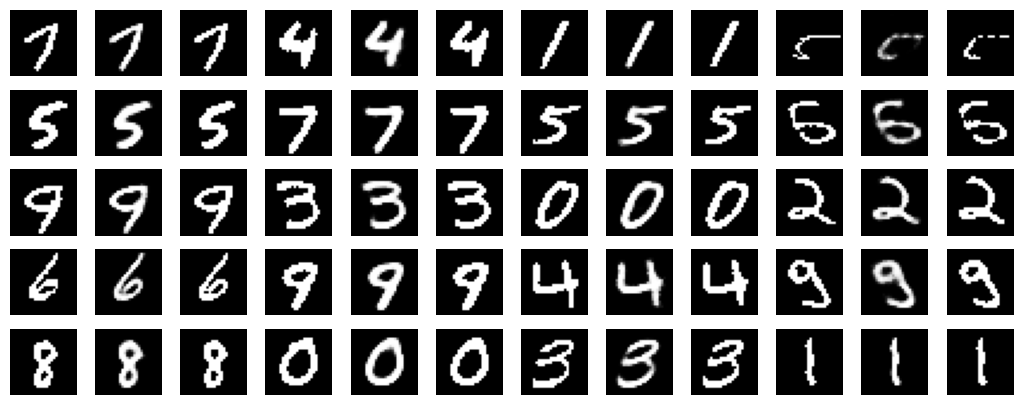

In [39]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae.decode(model_vae.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [38]:
activeUnits(model_vae, trainImageData)

dim 0: Var_x[mu] = 1.608828  (active)
dim 1: Var_x[mu] = 1.574898  (active)
dim 2: Var_x[mu] = 1.675152  (active)
dim 3: Var_x[mu] = 1.446522  (active)
dim 4: Var_x[mu] = 1.642333  (active)
dim 5: Var_x[mu] = 1.496365  (active)
dim 6: Var_x[mu] = 1.305810  (active)
dim 7: Var_x[mu] = 1.254616  (active)
dim 8: Var_x[mu] = 1.642946  (active)
dim 9: Var_x[mu] = 1.403147  (active)
dim 10: Var_x[mu] = 1.525403  (active)
dim 11: Var_x[mu] = 1.591839  (active)
dim 12: Var_x[mu] = 1.791127  (active)
dim 13: Var_x[mu] = 1.940885  (active)
dim 14: Var_x[mu] = 1.361313  (active)
dim 15: Var_x[mu] = 1.553793  (active)
16/16 active units (threshold=0.01)


tensor([1.6088, 1.5749, 1.6752, 1.4465, 1.6423, 1.4964, 1.3058, 1.2546, 1.6429,
        1.4031, 1.5254, 1.5918, 1.7911, 1.9409, 1.3613, 1.5538])